# 🧪 Lab 02: Engenharia de Atributos e Seleção de Features
**Módulo:** `01-machine-learning / tabular-data-analysis`

## Objetivos
1. Criar novas variáveis explicativas (*ratios*, binning/discretização) a partir de atributos brutos.
2. Aplicar **transformações logarítmicas** para normalizar distribuições assimétricas (*skewed data*).
3. Avaliar a importância de atributos usando estatística (`SelectKBest`) e árvores de decisão (`RandomForestClassifier`).
4. Reduzir a dimensão do dataset mantendo apenas as características de maior impacto preditivo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

# Configuração gráfica
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Criação de Dataset e Engenharia de Atributos (*Feature Engineering*)

In [2]:
# Dados sintéticos de perfil financeiro de clientes
np.random.seed(42)
n_amostras = 500

df = pd.DataFrame({
    'renda_anual': np.random.exponential(scale=50000, size=n_amostras) + 15000,
    'divida_total': np.random.uniform(1000, 80000, size=n_amostras),
    'idade': np.random.randint(18, 70, size=n_amostras),
    'score_credito': np.random.randint(300, 850, size=n_amostras),
    'ruido_aleatorio': np.random.normal(0, 1, size=n_amostras)  # Variável sem valor preditivo
})

# Target: 1 se inadimplente, 0 caso contrário (regra sintética)
df['inadimplente'] = np.where(
    (df['divida_total'] / df['renda_anual'] > 0.8) | (df['score_credito'] < 500), 1, 0
)

# --- ENGENHARIA DE ATRIBUTOS ---
# 1. Razão Dívida/Renda (Debt-to-Income Ratio)
df['racio_divida_renda'] = df['divida_total'] / df['renda_anual']

# 2. Transformação Logarítmica para suavizar assimetria da renda
df['log_renda_anual'] = np.log1p(df['renda_anual'])

# 3. Discretização/Binning da Idade (Faixas Etárias)
df['faixa_etaria'] = pd.cut(df['idade'], bins=[17, 30, 50, 100], labels=[0, 1, 2]).astype(int)

print("--- Primeiras linhas com os novos atributos criados ---")
display(df.head())

--- Primeiras linhas com os novos atributos criados ---


,renda_anual,divida_total,idade,score_credito,ruido_aleatorio,inadimplente,racio_divida_renda,log_renda_anual,faixa_etaria
0,38463.404499,56154.775408,64,563,-0.088343,1,1.459953,10.557489,2
1,165506.071546,43351.612941,29,617,0.921350,0,0.261934,12.016769,0
2,80837.284677,25452.681687,33,383,1.410568,1,0.314863,11.300206,1
3,60647.127689,65289.806557,41,617,1.214479,1,1.076552,11.012844,1
4,23481.243523,55093.762632,36,410,0.276544,1,2.346288,10.064000,1


## 2. Visualização do Impacto das Transformações

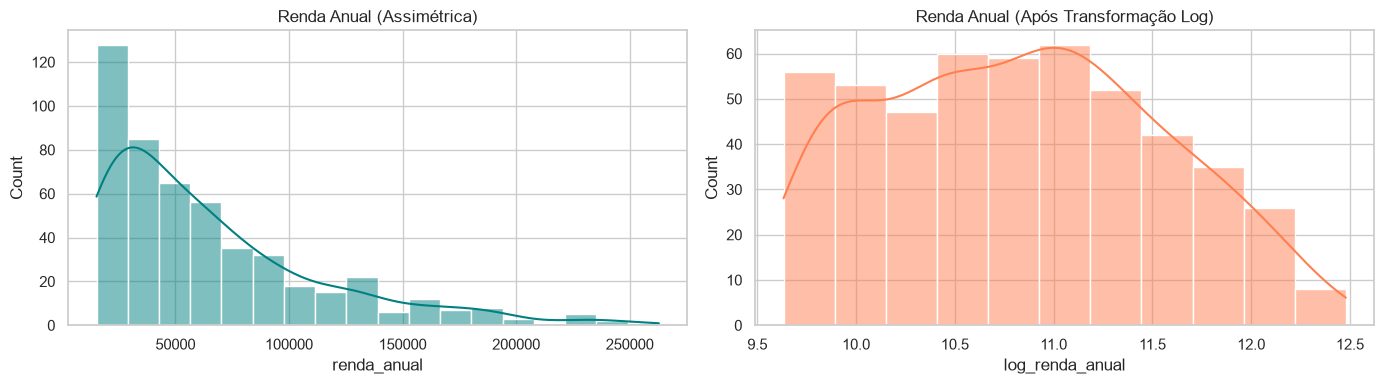

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# Distribuição da Renda Bruta vs Renda Logarítmica
sns.histplot(df['renda_anual'], kde=True, ax=ax[0], color='teal')
ax[0].set_title('Renda Anual (Assimétrica)')

sns.histplot(df['log_renda_anual'], kde=True, ax=ax[1], color='coral')
ax[1].set_title('Renda Anual (Após Transformação Log)')

plt.tight_layout()
plt.show()

## 3. Seleção de Atributos (*Feature Selection*)

--- Ranking de Atributos por SelectKBest ---


,Atributo,Score_F
5,racio_divida_renda,155.547222
3,score_credito,137.182413
1,divida_total,87.788816
6,log_renda_anual,76.746459
0,renda_anual,59.913452
7,faixa_etaria,1.020586
4,ruido_aleatorio,0.891284
2,idade,0.582711


C:\Users\lgularte\AppData\Local\Temp\ipykernel_26784\2427174814.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_rf_importance, x='Importancia', y='Atributo', palette='viridis')


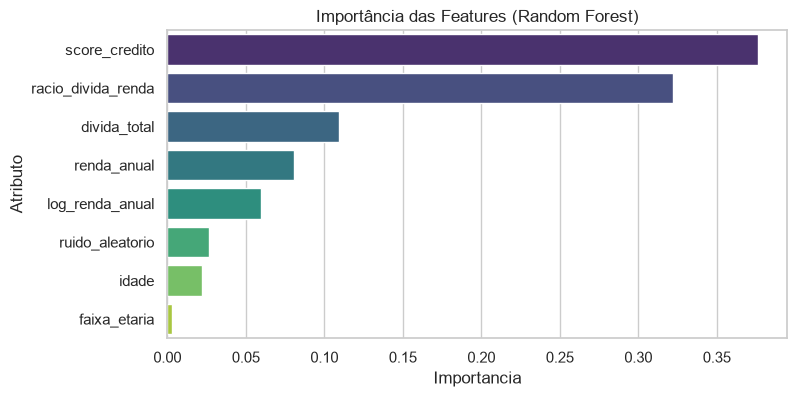

In [4]:
X = df.drop(columns=['inadimplente'])
y = df['inadimplente']

# Método 1: SelectKBest (Teste F de ANOVA)
selector = SelectKBest(score_func=f_classif, k=4)
selector.fit(X, y)

df_scores = pd.DataFrame({
    'Atributo': X.columns,
    'Score_F': selector.scores_
}).sort_values(by='Score_F', ascending=False)

print("--- Ranking de Atributos por SelectKBest ---")
display(df_scores)

# Método 2: Importância de Atributos via Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

df_rf_importance = pd.DataFrame({
    'Atributo': X.columns,
    'Importancia': rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=df_rf_importance, x='Importancia', y='Atributo', palette='viridis')
plt.title('Importância das Features (Random Forest)')
plt.show()

## 4. Conclusões

- A criação da razão `racio_divida_renda` capturou diretamente a relação de risco financeiro.
- A transformação `log_renda_anual` reduziu o impacto de valores extremos (*outliers* positivos).
- A análise de relevância identificou que a variável `ruido_aleatorio` tem baixo valor preditivo, podendo ser descartada para simplificar o modelo.